***DenseNet***

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Dense Layer

In [9]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        out = torch.cat([x, out], 1)
        return out

Dense Block

In [10]:
class DenseBlock(nn.Module):
    def __init__(self, in_channels, num_layers, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

Transition Layer

In [11]:
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(2, stride=2)

    def forward(self, x):
        x = self.conv(self.relu(self.bn(x)))
        x = self.pool(x)
        return x

DenseNet Model for CIFAR-10

In [12]:
class DenseNet(nn.Module):
    def __init__(self, growth_rate=12, num_classes=10):
        super(DenseNet, self).__init__()

        # Initial convolution for RGB images
        self.conv1 = nn.Conv2d(3, 2 * growth_rate, kernel_size=3, padding=1, bias=False)

        num_channels = 2 * growth_rate
        self.block1 = DenseBlock(num_channels, num_layers=6, growth_rate=growth_rate)
        num_channels += 6 * growth_rate
        self.trans1 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2

        self.block2 = DenseBlock(num_channels, num_layers=6, growth_rate=growth_rate)
        num_channels += 6 * growth_rate
        self.trans2 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2

        self.block3 = DenseBlock(num_channels, num_layers=6, growth_rate=growth_rate)
        num_channels += 6 * growth_rate

        self.bn = nn.BatchNorm2d(num_channels)
        self.fc = nn.Linear(num_channels, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.block1(x)
        x = self.trans1(x)
        x = self.block2(x)
        x = self.trans2(x)
        x = self.block3(x)
        x = self.bn(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

Training, Evaluation & Prediction

In [13]:
def train_model(model, train_loader, test_loader, device, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")

        acc = evaluate(model, test_loader, device)
        print(f"Test Accuracy: {acc:.2f}%\n")

def evaluate(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def show_predictions(model, test_loader, device, n=6):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images[:n].to(device), labels[:n].to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(10, 3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i].permute(1, 2, 0).cpu()
        plt.imshow((img - img.min()) / (img.max() - img.min()))
        plt.title(f"P:{preds[i].item()} / T:{labels[i].item()}")
        plt.axis("off")
    plt.show()

Main Section

100%|██████████| 170M/170M [00:17<00:00, 9.62MB/s]


Training DenseNet on CIFAR-10...
Epoch [1/10] Loss: 1.2981
Test Accuracy: 58.50%

Epoch [2/10] Loss: 0.9149
Test Accuracy: 62.43%

Epoch [3/10] Loss: 0.7684
Test Accuracy: 68.54%

Epoch [4/10] Loss: 0.6660
Test Accuracy: 75.24%

Epoch [5/10] Loss: 0.5816
Test Accuracy: 77.41%

Epoch [6/10] Loss: 0.5264
Test Accuracy: 79.47%

Epoch [7/10] Loss: 0.4792
Test Accuracy: 79.59%

Epoch [8/10] Loss: 0.4401
Test Accuracy: 81.34%

Epoch [9/10] Loss: 0.4084
Test Accuracy: 81.41%

Epoch [10/10] Loss: 0.3735
Test Accuracy: 80.42%

Sample Predictions:


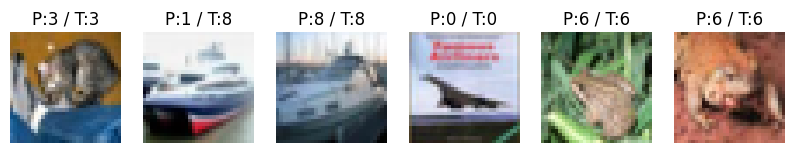

In [14]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # CIFAR-10 dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    train_set = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
    test_set = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

    model = DenseNet().to(device)
    print("Training DenseNet on CIFAR-10...")
    train_model(model, train_loader, test_loader, device, epochs=10)

    print("Sample Predictions:")
    show_predictions(model, test_loader, device)